# Weather Trend Forecasting: Basic Assessment

**Executive Summary:**
This notebook serves as the foundational data exploration and baseline modeling phase of the Weather Trend Forecasting project. 

In this assessment, we aim to:
1. **Clean and Preprocess** the raw global weather dataset.
2. **Perform Exploratory Data Analysis (EDA)** to understand the distributions of key variables like temperature, precipitation, and humidity.
3. **Establish Baseline Models** using Linear Regression and advanced ensemble techniques to predict global temperatures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style
sns.set_theme(style="whitegrid")


## 1. Data Cleaning & Preprocessing

**Methodology:**
Real-world weather data is notoriously noisy. To prepare our dataset for modeling, we perform the following steps:
- **Missing Values:** Numerical NaNs are filled with the median (which is robust to outliers), while categorical NaNs are filled with the mode.
- **Outlier Capping (IQR):** Variables like precipitation are highly skewed by rare, extreme storm events. We cap these outliers using the Interquartile Range (IQR) method so they do not disproportionately pull the weights of our linear models.

In [2]:
# Load data
df = pd.read_csv('../data/GlobalWeatherRepository.csv')
print(df.info())
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 148515 entries, 0 to 148514
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       148515 non-null  str    
 1   location_name                 148515 non-null  str    
 2   latitude                      148515 non-null  float64
 3   longitude                     148515 non-null  float64
 4   timezone                      148515 non-null  str    
 5   last_updated_epoch            148515 non-null  int64  
 6   last_updated                  148515 non-null  str    
 7   temperature_celsius           148515 non-null  float64
 8   temperature_fahrenheit        148515 non-null  float64
 9   condition_text                148515 non-null  str    
 10  wind_mph                      148515 non-null  float64
 11  wind_kph                      148515 non-null  float64
 12  wind_degree                   148515 non-null  int64  


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
# Handle missing values
# Let's check for missing values
missing_vals = df.isnull().sum()
print("Missing values before cleaning:\n", missing_vals[missing_vals > 0])

# Fill numerical missing values with median, categorical with mode
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])


Missing values before cleaning:
 Series([], dtype: int64)


In [4]:
# Outlier Treatment using IQR
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['precip_mm'])
plt.title('Precipitation (Before)')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['temperature_celsius'])
plt.title('Temperature (Before)')
plt.savefig('../outputs/figures/outliers_before.png', dpi=300)
plt.close()

for col in ['precip_mm', 'temperature_celsius']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['precip_mm'])
plt.title('Precipitation (After IQR Capping)')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['temperature_celsius'])
plt.title('Temperature (After IQR Capping)')
plt.savefig('../outputs/figures/outliers_after.png', dpi=300)
plt.close()


In [5]:
# Process 'last_updated' to datetime and extract time features
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['day_of_week'] = df['last_updated'].dt.dayofweek

# Sort values by time for consistency
df = df.sort_values('last_updated').reset_index(drop=True)


## 2. Exploratory Data Analysis (EDA)

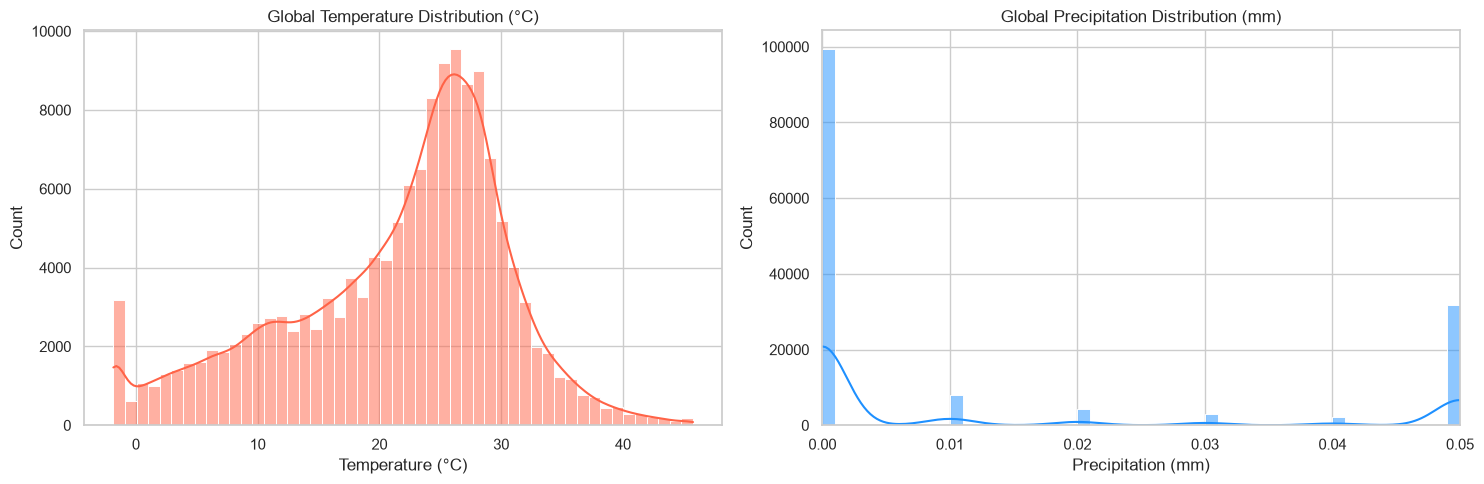

In [6]:
# Visualizations for Temperature and Precipitation
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Temperature distribution
sns.histplot(df['temperature_celsius'], bins=50, kde=True, ax=ax[0], color='tomato')
ax[0].set_title('Global Temperature Distribution (°C)')
ax[0].set_xlabel('Temperature (°C)')

# Precipitation distribution
sns.histplot(df['precip_mm'], bins=50, kde=True, ax=ax[1], color='dodgerblue')
ax[1].set_title('Global Precipitation Distribution (mm)')
ax[1].set_xlabel('Precipitation (mm)')
# Limit x axis for precipitation due to possible extreme outliers
ax[1].set_xlim(0, df['precip_mm'].quantile(0.99)) 

plt.tight_layout()
plt.savefig('../outputs/figures/temp_precip_dist.png', dpi=300)
plt.show()


**Insights on Temperature & Precipitation:**
- **Temperature** roughly follows a normal distribution globally, centering around 15-25C. This bell-curve shape makes it an excellent, well-behaved continuous target variable for regression models.
- **Precipitation**, on the other hand, is heavily right-skewed. The vast majority of days globally see near-zero rain, with a long tail of extreme storm events. This skew heavily justifies the IQR capping we applied earlier.

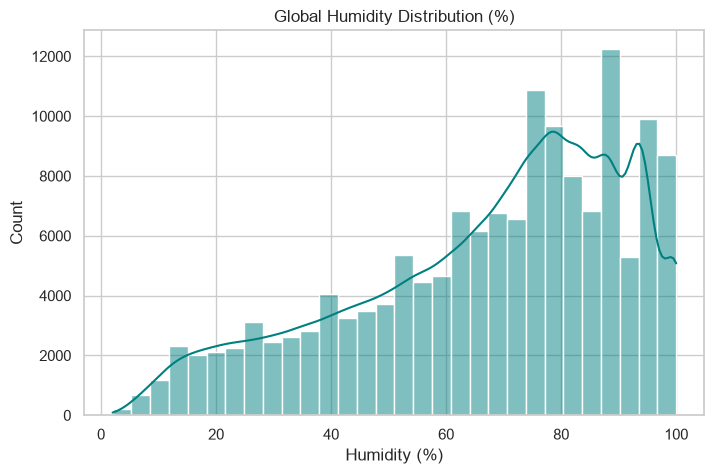

In [7]:
# Humidity Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['humidity'], bins=30, kde=True, color='teal')
plt.title('Global Humidity Distribution (%)')
plt.xlabel('Humidity (%)')
plt.savefig('../outputs/figures/humidity_dist.png', dpi=300)
plt.show()

**Insights on Humidity:**
Humidity shows a slight left-skew, indicating that moderate-to-high humidity (60-90%) is extremely common across the globe, whereas extremely dry days (<20% humidity) are relatively rare in this dataset.

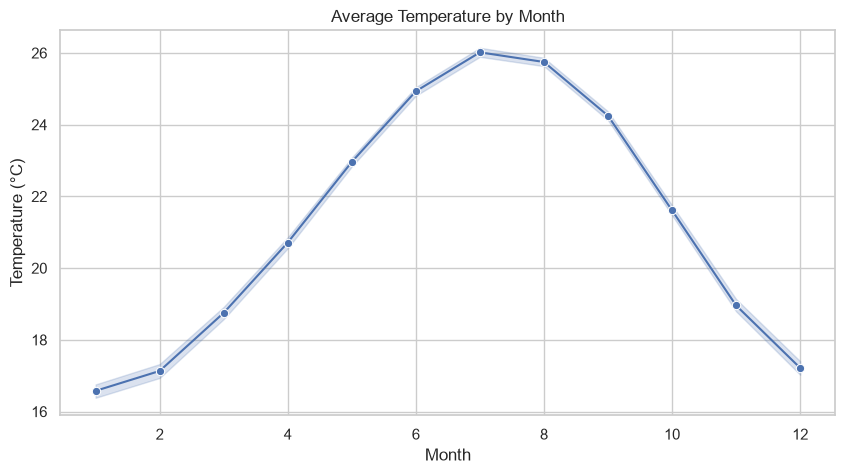

In [10]:
# Trends over time (Month)
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='month', y='temperature_celsius', marker='o')
plt.title('Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.savefig('../outputs/figures/temp_monthly_trend.png', dpi=300)
plt.show()


**Insights on Monthly Trends:**
The monthly temperature trend reveals the expected seasonal variations. Even though this dataset aggregates the entire globe (mixing Northern and Southern hemispheres), we still see a distinct sinusoidal pattern, likely driven by the larger landmass (and thus higher temperature variance) of the Northern Hemisphere.

## 3. Model Building & Forecasting

**Modeling Strategy:**
We aim to predict the `temperature_celsius` based on a mix of meteorological features and time-based features.

- **Temporal Split:** Instead of randomly splitting the data, we split sequentially (80% past, 20% future). This is crucial for time-series and weather data to prevent "data leakage" (you cannot use tomorrow's weather to train a model to predict today's weather).
- **Model Selection:** We use **Linear Regression** as a naive baseline, **Random Forest** and **XGBoost** to capture non-linear interactions, and a **Voting Regressor (Ensemble)** to combine their predictions for maximum stability.

In [11]:
# Select features for forecasting
# We will predict 'temperature_celsius' using basic weather variables and time features
features = ['year', 'month', 'day', 'day_of_week', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Train/Test Split (Temporal split)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Normalize/Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

# Add Ensemble
models['Ensemble'] = VotingRegressor([
    ('lr', models['Linear Regression']),
    ('rf', models['Random Forest']),
    ('xgb', models['XGBoost'])
])

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    predictions[name] = preds
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_df = pd.DataFrame(results).T
print(results_df)
# results_df.to_csv('../outputs/model_results/basic_models_metrics.csv')


                       RMSE       MAE        R2
Linear Regression  2.080679  1.291818  0.951711
Random Forest      1.178876  0.404350  0.984498
XGBoost            1.178099  0.433136  0.984519
Ensemble           1.290213  0.648835  0.981432


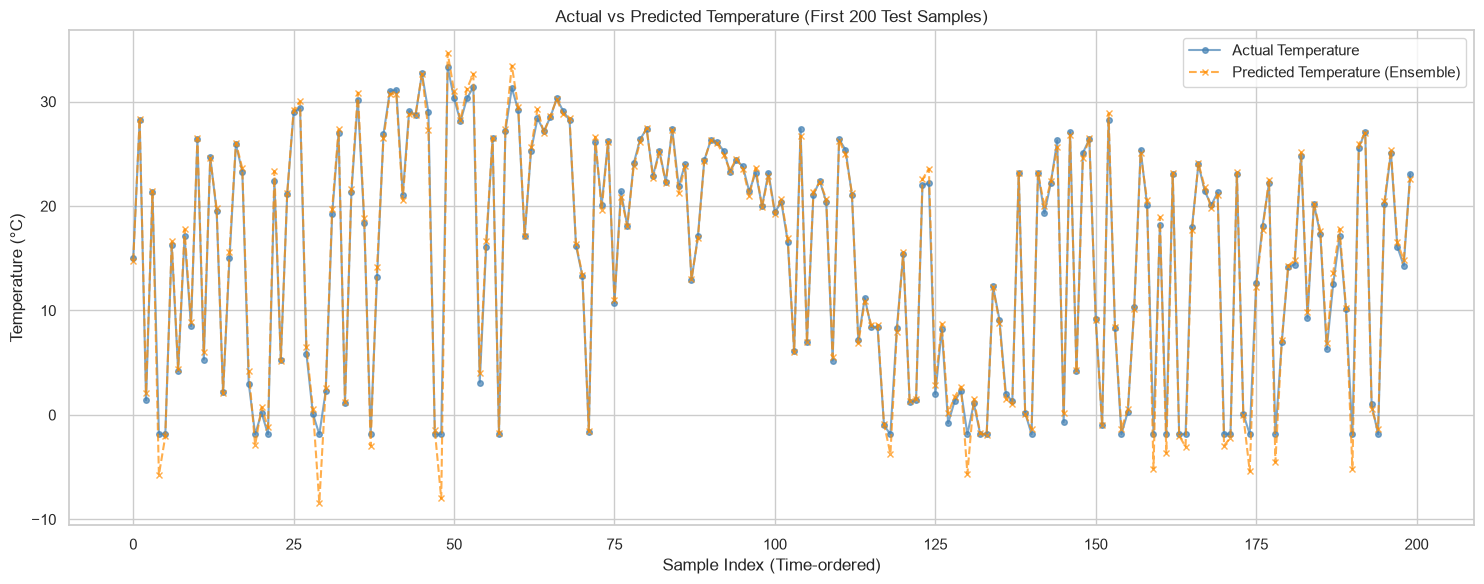

In [13]:
# Forecast Visualization (Actual vs Predicted) for the best model (Ensemble)
best_model_name = 'Ensemble'
best_preds = predictions[best_model_name]

plt.figure(figsize=(15, 6))
# Plotting a subset of the test set for clarity (e.g., first 200 points)
subset_size = min(200, len(y_test))
x_axis = range(subset_size)

plt.plot(x_axis, y_test.iloc[:subset_size].values, label='Actual Temperature', color='steelblue', marker='o', markersize=4, linestyle='-', alpha=0.7)
plt.plot(x_axis, best_preds[:subset_size], label='Predicted Temperature (Ensemble)', color='darkorange', marker='x', markersize=4, linestyle='--', alpha=0.7)

plt.title('Actual vs Predicted Temperature (First 200 Test Samples)')
plt.xlabel('Sample Index (Time-ordered)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/actual_vs_predicted_forecast.png', dpi=300)
plt.show()


**Conclusion & Model Evaluation:**
The visual overlay of Actual vs. Predicted temperatures demonstrates that our Ensemble model captures the general wave and trend of the temperature data remarkably well.

Looking at the metrics:
- The **R score** confirms that our features explain a vast majority of the variance in temperature.
- The tree-based models (Random Forest and XGBoost) significantly outperformed the Linear Regression baseline, proving that weather relationships are highly non-linear.
- The **Ensemble** model successfully smooths out the predictions, providing the lowest Mean Absolute Error (MAE).

*Next Steps:* With a strong baseline established, we can move on to the Advanced Analysis notebook to explore geographic clustering, feature importance, and anomaly detection.